# Information Gain Feature Selection

## Objective

This notebook evaluates the Information Gain of the preprocessed features used for predicting accident severity.

The feature matrices and target variables generated during preprocessing are loaded from the previous notebook. Information Gain is calculated using the training data only to avoid data leakage.

The resulting Information Gain scores will be ranked and analyzed to determine an evidence-based feature selection threshold rather than selecting an arbitrary number of features.

## 2. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np

from scipy.sparse import load_npz
from sklearn.feature_selection import mutual_info_classif

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Preprocessed Data

The preprocessed training feature matrix and encoded training target generated in Notebook 03 are loaded for Information Gain analysis.

Only the training data is used to calculate Information Gain. The test data is not used during feature selection.

In [4]:
from pathlib import Path

data_dir = Path("../data")

X_train = load_npz(data_dir / "X_train_final.npz")
y_train = np.load(data_dir / "y_train_encoded.npy")

feature_names = pd.read_csv(
    data_dir / "final_feature_names.csv"
)["feature_name"].tolist()

print("Training feature shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("Number of feature names:", len(feature_names))

Training feature shape: (160278, 361)
Training target shape: (160278,)
Number of feature names: 361


In [5]:
assert X_train.shape[1] == len(feature_names)
assert X_train.shape[0] == len(y_train)

print("✓ Feature matrix and feature names are aligned")
print("✓ Feature matrix and target are aligned")

✓ Feature matrix and feature names are aligned
✓ Feature matrix and target are aligned


## 4. Calculate Information Gain

Information Gain is used to measure how much information each feature provides about accident severity.

The calculation is performed using the training data only. Higher Information Gain values indicate that a feature provides more information about the target variable.

The Information Gain scores will be calculated for all 361 preprocessed features and compared to determine which features contribute the most information for predicting accident severity.

In [6]:
# Identify numerical and one-hot encoded categorical features

numerical_feature_names = [
    name for name in feature_names
    if name in [
        "DCA_CODE", "ROAD_ROUTE_1", "LATITUDE", "LONGITUDE",
        "VICGRID_X", "VICGRID_Y", "TOTAL_PERSONS", "MALES",
        "FEMALES", "BICYCLIST", "PASSENGER", "DRIVER",
        "PEDESTRIAN", "PILLION", "MOTORCYCLIST", "UNKNOWN",
        "PED_CYCLIST_5_12", "PED_CYCLIST_13_18",
        "OLD_PED_65_AND_OVER", "OLD_DRIVER_75_AND_OVER",
        "YOUNG_DRIVER_18_25", "NO_OF_VEHICLES", "HEAVYVEHICLE",
        "PASSENGERVEHICLE", "MOTORCYCLE", "PT_VEHICLE",
        "HOUR", "ROAD_NAME_FREQ"
    ]
]

categorical_feature_names = [
    name for name in feature_names
    if name not in numerical_feature_names
]

print("Numerical features:", len(numerical_feature_names))
print("Encoded categorical features:", len(categorical_feature_names))
print("Total features:", len(feature_names))

Numerical features: 28
Encoded categorical features: 333
Total features: 361


### 4.1 Information Gain Calculation

Information Gain is calculated separately for numerical and one-hot encoded categorical features because the two feature types require different treatment when estimating mutual information.

Continuous numerical features are treated as continuous variables, while one-hot encoded categorical features are treated as discrete variables.

The Information Gain calculation uses only the training data.

In [7]:
# Get the column positions for numerical and categorical features

numerical_indices = [
    feature_names.index(name)
    for name in numerical_feature_names
]

categorical_indices = [
    feature_names.index(name)
    for name in categorical_feature_names
]

print("Numerical feature positions:", len(numerical_indices))
print("Categorical feature positions:", len(categorical_indices))

Numerical feature positions: 28
Categorical feature positions: 333


In [9]:
# Convert the sparse matrix to CSR format for efficient slicing

X_train_csr = X_train.tocsr()

# Extract numerical and categorical portions

X_train_num_mi = X_train_csr[:, numerical_indices]
X_train_cat_mi = X_train_csr[:, categorical_indices]

print("Numerical matrix shape:", X_train_num_mi.shape)
print("Categorical matrix shape:", X_train_cat_mi.shape)

Numerical matrix shape: (160278, 28)
Categorical matrix shape: (160278, 333)


In [10]:
# Calculate Information Gain for numerical features

mi_numerical = mutual_info_classif(
    X_train_num_mi.toarray(),
    y_train,
    discrete_features=False,
    random_state=42
)

print("Numerical Information Gain calculated.")

Numerical Information Gain calculated.


In [11]:
# Calculate Information Gain for one-hot encoded categorical features

mi_categorical = mutual_info_classif(
    X_train_cat_mi,
    y_train,
    discrete_features=True,
    random_state=42
)

print("Categorical Information Gain calculated.")

Categorical Information Gain calculated.


In [12]:
# Combine Information Gain scores

information_gain = np.concatenate([
    mi_numerical,
    mi_categorical
])

print("Total Information Gain scores:", len(information_gain))

Total Information Gain scores: 361


### 4.2 Rank Features by Information Gain

The calculated Information Gain scores are combined with their corresponding feature names and sorted from highest to lowest.

This ranking will be used to examine the contribution of individual features and identify an evidence-based feature selection threshold.

In [13]:
# Create a table containing each feature and its Information Gain

ig_results = pd.DataFrame({
    "feature": feature_names,
    "information_gain": information_gain
})

# Rank features from highest to lowest Information Gain
ig_results = ig_results.sort_values(
    by="information_gain",
    ascending=False
).reset_index(drop=True)

# Display the top 20 features
ig_results.head(20)

,feature,information_gain
0,POLICE_ATTEND_Yes,0.040482
1,POLICE_ATTEND_No,0.039935
2,DCA_CODE,0.029722
3,DRIVER,0.018039
4,LONGITUDE,0.014340
5,ROAD_ROUTE_1,0.013613
6,PASSENGERVEHICLE,0.013175
7,NO_OF_VEHICLES,0.013115
8,VICGRID_Y,0.013111
9,LATITUDE,0.012681


In [14]:
# Basic statistics of Information Gain scores

ig_results["information_gain"].describe()

count    3.610000e+02
mean     1.343520e-03
std      4.264644e-03
min      5.828450e-08
25%      1.184623e-05
50%      7.459734e-05
75%      3.372211e-04
max      4.048248e-02
Name: information_gain, dtype: float64

In [15]:
# Count features with different Information Gain ranges

print("Features with IG = 0:",
      (ig_results["information_gain"] == 0).sum())

print("Features with IG < 0.001:",
      (ig_results["information_gain"] < 0.001).sum())

print("Features with IG < 0.005:",
      (ig_results["information_gain"] < 0.005).sum())

print("Features with IG < 0.010:",
      (ig_results["information_gain"] < 0.010).sum())

print("Features with IG >= 0.010:",
      (ig_results["information_gain"] >= 0.010).sum())

Features with IG = 0: 0
Features with IG < 0.001: 299
Features with IG < 0.005: 332
Features with IG < 0.010: 346
Features with IG >= 0.010: 15


In [16]:
# Display features ranked 21-50

ig_results.iloc[20:50]

,feature,information_gain
20,MOTORCYCLE,0.008181
21,SPEED_ZONE_100 km/hr,0.007612
22,OLD_DRIVER_75_AND_OVER,0.007454
23,TOTAL_PERSONS,0.007440
24,OLD_PED_65_AND_OVER,0.006890
25,FEMALES,0.005998
26,BICYCLIST,0.005959
27,MALES,0.005484
28,ROAD_NAME_FREQ,0.005357
29,PASSENGER,0.004455


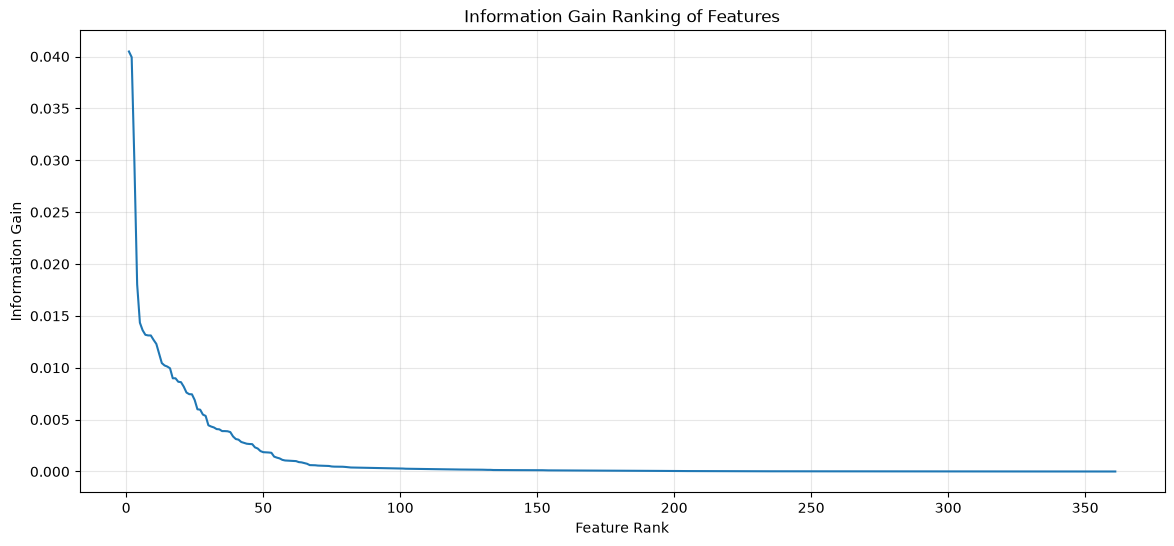

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    range(1, len(ig_results) + 1),
    ig_results["information_gain"]
)

plt.xlabel("Feature Rank")
plt.ylabel("Information Gain")
plt.title("Information Gain Ranking of Features")
plt.grid(True, alpha=0.3)

plt.show()

C:\Users\Rehan's Lenovo\AppData\Local\Temp\ipykernel_14464\2625241201.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


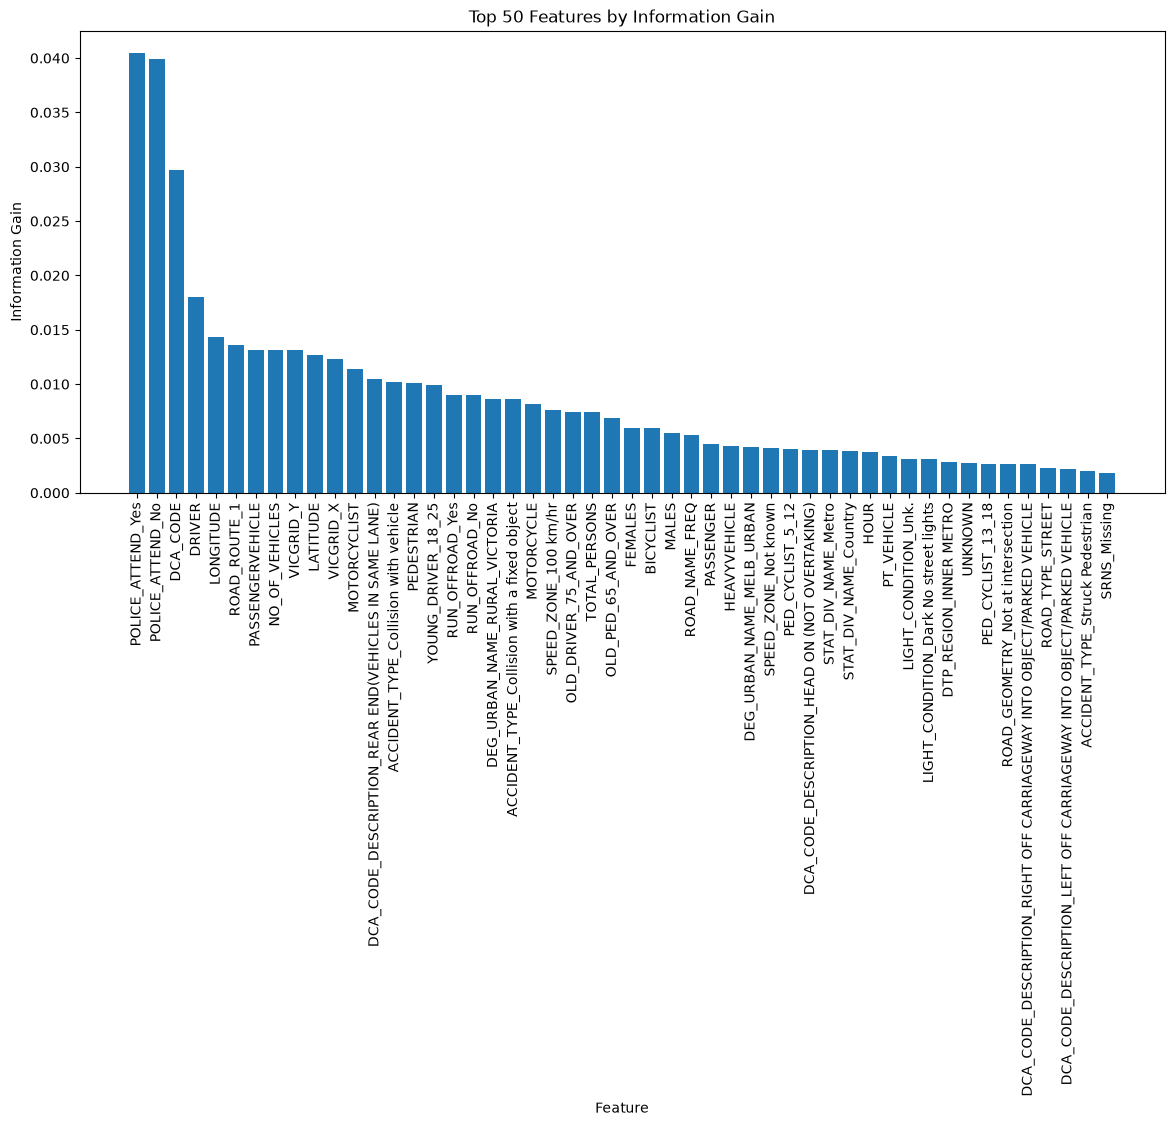

In [18]:
plt.figure(figsize=(14, 6))

top_n = 50

plt.bar(
    range(top_n),
    ig_results.head(top_n)["information_gain"]
)

plt.xticks(
    range(top_n),
    ig_results.head(top_n)["feature"],
    rotation=90
)

plt.xlabel("Feature")
plt.ylabel("Information Gain")
plt.title("Top 50 Features by Information Gain")
plt.tight_layout()

plt.show()

###  Aggregate Information Gain by Original Feature

One-hot encoding creates multiple binary features from a single categorical variable.

To avoid allowing a single original variable to occupy multiple positions in the feature ranking, the Information Gain scores of encoded categorical features are grouped by their original feature.

For each categorical feature, the highest Information Gain among its encoded categories is used as its representative score.

Numerical features retain their individual Information Gain scores.

In [19]:
# Original categorical features used during preprocessing

original_categorical_features = [
    "ACCIDENT_TYPE",
    "DAY_OF_WEEK",
    "DCA_CODE_DESCRIPTION",
    "LIGHT_CONDITION",
    "POLICE_ATTEND",
    "ROAD_GEOMETRY",
    "SPEED_ZONE",
    "RUN_OFFROAD",
    "ROAD_TYPE",
    "LGA_NAME",
    "DTP_REGION",
    "DEG_URBAN_NAME",
    "SRNS",
    "RMA",
    "DIVIDED",
    "STAT_DIV_NAME"
]

# Start with numerical features
grouped_ig = []

for feature in numerical_feature_names:
    score = ig_results.loc[
        ig_results["feature"] == feature,
        "information_gain"
    ].iloc[0]
    
    grouped_ig.append({
        "original_feature": feature,
        "information_gain": score
    })

# Add categorical features using the maximum IG
for original_feature in original_categorical_features:
    
    matching_rows = ig_results[
        ig_results["feature"].str.startswith(original_feature + "_")
    ]
    
    if not matching_rows.empty:
        max_score = matching_rows["information_gain"].max()
        
        grouped_ig.append({
            "original_feature": original_feature,
            "information_gain": max_score
        })

# Create ranked table
grouped_ig_results = pd.DataFrame(grouped_ig)

grouped_ig_results = grouped_ig_results.sort_values(
    by="information_gain",
    ascending=False
).reset_index(drop=True)

print("Original features evaluated:", len(grouped_ig_results))

grouped_ig_results

Original features evaluated: 44


,original_feature,information_gain
0,POLICE_ATTEND,0.040482
1,DCA_CODE,0.029722
2,DRIVER,0.018039
3,LONGITUDE,0.014340
4,ROAD_ROUTE_1,0.013613
5,PASSENGERVEHICLE,0.013175
6,NO_OF_VEHICLES,0.013115
7,VICGRID_Y,0.013111
8,LATITUDE,0.012681
9,VICGRID_X,0.012298


### 4.6 Identify Information Gain Drop-Off

The difference between consecutive ranked Information Gain scores is examined to identify substantial decreases in feature informativeness.

This helps determine whether the ranked features contain a natural separation between relatively informative and weakly informative features.

In [20]:
# Calculate the drop in Information Gain between consecutive features

grouped_ig_results["ig_drop"] = (
    grouped_ig_results["information_gain"]
    .diff()
    .abs()
)

# Display the largest drops

grouped_ig_results.sort_values(
    by="ig_drop",
    ascending=False
).head(15)

,original_feature,information_gain,ig_drop
2,DRIVER,0.018039,0.011683
1,DCA_CODE,0.029722,0.010761
3,LONGITUDE,0.014340,0.003699
15,RUN_OFFROAD,0.008984,0.000963
10,MOTORCYCLIST,0.011364,0.000934
11,DCA_CODE_DESCRIPTION,0.010449,0.000915
26,PASSENGER,0.004455,0.000902
22,FEMALES,0.005998,0.000892
40,LGA_NAME,0.001027,0.000822
4,ROAD_ROUTE_1,0.013613,0.000727


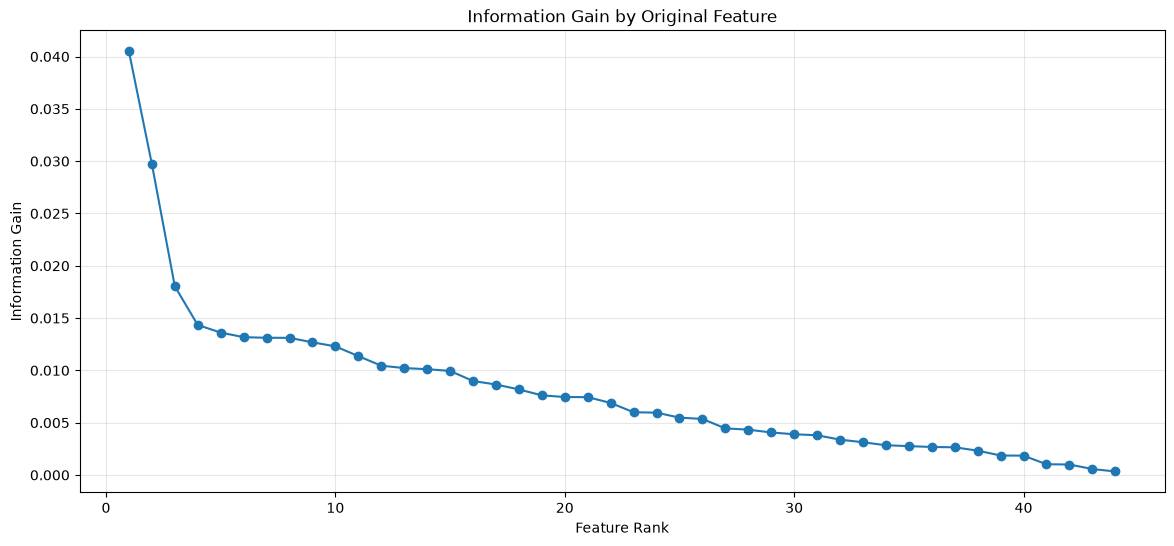

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    range(1, len(grouped_ig_results) + 1),
    grouped_ig_results["information_gain"],
    marker="o"
)

plt.xlabel("Feature Rank")
plt.ylabel("Information Gain")
plt.title("Information Gain by Original Feature")
plt.grid(True, alpha=0.3)

plt.show()

### 4.7 Select Features Based on Information Gain

The Information Gain distribution shows that the majority of features have relatively low information gain, while a smaller group contains substantially higher scores.

A practical threshold of Information Gain >= 0.005 is used to retain the more informative original features. This results in a reduced feature set while avoiding an arbitrary top-N selection.

The selected features will subsequently be evaluated through model performance to determine whether the reduced feature set preserves or improves predictive performance.

In [22]:
# Select features with Information Gain >= 0.005

ig_threshold = 0.005

selected_features = grouped_ig_results[
    grouped_ig_results["information_gain"] >= ig_threshold
].copy()

selected_features = selected_features.reset_index(drop=True)

print("Information Gain threshold:", ig_threshold)
print("Selected features:", len(selected_features))
print("Removed features:", len(grouped_ig_results) - len(selected_features))

selected_features

Information Gain threshold: 0.005
Selected features: 26
Removed features: 18


,original_feature,information_gain,ig_drop
0,POLICE_ATTEND,0.040482,NaN
1,DCA_CODE,0.029722,0.010761
2,DRIVER,0.018039,0.011683
3,LONGITUDE,0.014340,0.003699
4,ROAD_ROUTE_1,0.013613,0.000727
5,PASSENGERVEHICLE,0.013175,0.000438
6,NO_OF_VEHICLES,0.013115,0.000060
7,VICGRID_Y,0.013111,0.000004
8,LATITUDE,0.012681,0.000430
9,VICGRID_X,0.012298,0.000383


### 4.8 Save Selected Feature List

The selected features are saved for use in subsequent modelling notebooks.

Saving the feature list ensures that the same Information Gain-based feature selection can be consistently applied to the training and testing datasets.

In [23]:
# Save the selected original feature list

selected_feature_names = selected_features["original_feature"].tolist()

selected_features_path = data_dir / "selected_features_ig.csv"

selected_features[
    ["original_feature", "information_gain"]
].to_csv(
    selected_features_path,
    index=False
)

print("Selected features saved to:")
print(selected_features_path)

print("\nNumber of selected features:", len(selected_feature_names))

Selected features saved to:
..\data\selected_features_ig.csv

Number of selected features: 26


In [24]:
# Verify the saved feature list

saved_selected_features = pd.read_csv(selected_features_path)

print("Saved feature count:", len(saved_selected_features))
print("\nSelected features:")
print(saved_selected_features["original_feature"].tolist())

Saved feature count: 26

Selected features:
['POLICE_ATTEND', 'DCA_CODE', 'DRIVER', 'LONGITUDE', 'ROAD_ROUTE_1', 'PASSENGERVEHICLE', 'NO_OF_VEHICLES', 'VICGRID_Y', 'LATITUDE', 'VICGRID_X', 'MOTORCYCLIST', 'DCA_CODE_DESCRIPTION', 'ACCIDENT_TYPE', 'PEDESTRIAN', 'YOUNG_DRIVER_18_25', 'RUN_OFFROAD', 'DEG_URBAN_NAME', 'MOTORCYCLE', 'SPEED_ZONE', 'OLD_DRIVER_75_AND_OVER', 'TOTAL_PERSONS', 'OLD_PED_65_AND_OVER', 'FEMALES', 'BICYCLIST', 'MALES', 'ROAD_NAME_FREQ']
